<a href="https://colab.research.google.com/github/paolapeiz/Telemetria_Videojuegos/blob/main/practica_mineria_videojuegos_alumnos_guiada.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Práctica guiada de Minería de Datos para Ingeniería de Videojuegos

## Caso práctico
Trabajas en el equipo de **Game Analytics** de un estudio que gestiona un videojuego online multijugador.
Dispones de un dataset con telemetría agregada de jugadores y debes analizarlo para encontrar patrones de comportamiento y construir un modelo sencillo de **churn**.

## Qué se trabaja en esta práctica
- Comprensión del problema
- Calidad de datos
- Limpieza y transformación
- Exploración visual
- Reducción de dimensionalidad con **PCA**
- Modelo base de clasificación

## Instrucciones
- En algunas celdas ya tienes parte del código hecha.
- Tendrás que completar las zonas marcadas con `# TODO`.
- No se trata solo de ejecutar: **interpreta** lo que ves.


## 1. Importación de librerías

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

plt.figure(figsize=(8,5))
pd.set_option('display.max_columns', None)


<Figure size 800x500 with 0 Axes>

## 2. Carga del dataset

In [ ]:
ruta = 'videojuegos_online_telemetria.csv'

# ✅ TODO: carga el CSV en un DataFrame llamado df
df = pd.read_csv(ruta)

# ✅ TODO: muestra las 5 primeras filas
df.head()

,PlayerID,Age,Region,Platform,PreferredGenre,SessionsPerWeek,AvgSessionMinutes,DaysSinceLastLogin,PlayerLevel,MatchesPlayedLast30D,WinRate,InGamePurchase,FriendsInGame,UsesVoiceChat,AchievementsUnlocked,ReportsReceivedLast30D,Churn30D
0,P0001,22.0,LATAM,PC,RPG,3,87.0,11,59,14,0.481,7.38,3.0,1,17,0,0
1,P0002,21.0,EU,PC,Shooter,7,113.0,0,45,24,0.475,11.56,8.0,1,21,2,0
2,P0003,40.0,LATAM,Mobile,Shooter,3,67.0,3,68,27,0.341,0.42,6.0,1,26,1,0
3,P0004,37.0,NaN,PC,Shooter,0,48.0,9,40,39,0.225,8.83,NaN,1,41,2,0
4,P0005,28.0,EU,Console,Shooter,3,90.0,15,51,15,0.454,23.86,0.0,0,35,1,1


### Preguntas rápidas
1. ¿Qué representa cada fila?
Cada fila representa un jugador único y sus datos de telemetría agregada, incluyendo información demográfica, actividad dentro del juego y si ha abandonado el juego en los últimos 30 días

2. ¿Qué variable parece ser la variable objetivo?
La variable objetivo es Churn30D. El enunciado del problema menciona la construcción de un modelo de churn, y esta columna (0 o 1) indica si un jugador ha abandonado o no.

3. ¿Qué decisiones de producto o diseño podría apoyar este análisis?
Este análisis podría apoyar varias decisiones:

Estrategias de retención: Identificar las características de los jugadores propensos al churn para diseñar intervenciones y campañas de retención específicas.
Diseño de juego: Adaptar características del juego o equilibrar la dificultad basándose en patrones de juego que conduzcan a un mayor o menor churn.
Monetización: Entender cómo las compras dentro del juego (InGamePurchase) o el tiempo invertido (SessionsPerWeek, AvgSessionMinutes) se relacionan con la retención para optimizar las ofertas.
Gestión de la comunidad: Identificar si factores como FriendsInGame o UsesVoiceChat influyen en la lealtad de los jugadores para fomentar estas interacciones.
Detección temprana: Crear sistemas de alerta para identificar jugadores en riesgo de churn y actuar proactivamente.


## 3. Comprensión inicial del dataset

In [ ]:
print('Dimensiones del dataset:', df.shape)
print('\nTipos de datos:')
display(df.dtypes)

print('\nResumen estadístico de variables numéricas:')
display(df.describe())


Dimensiones del dataset: (558, 17)

Tipos de datos:


,0
PlayerID,object
Age,float64
Region,object
Platform,object
PreferredGenre,object
SessionsPerWeek,int64
AvgSessionMinutes,float64
DaysSinceLastLogin,int64
PlayerLevel,int64
MatchesPlayedLast30D,int64



Resumen estadístico de variables numéricas:


,Age,SessionsPerWeek,AvgSessionMinutes,DaysSinceLastLogin,PlayerLevel,MatchesPlayedLast30D,WinRate,InGamePurchase,FriendsInGame,UsesVoiceChat,AchievementsUnlocked,ReportsReceivedLast30D,Churn30D
count,546.000000,558.000000,546.000000,558.000000,558.000000,558.000000,546.000000,546.000000,546.000000,558.000000,558.000000,558.000000,558.000000
mean,27.893773,4.500000,78.578755,7.646953,35.127240,27.048387,0.512256,14.318462,7.569597,0.546595,22.206093,1.080645,0.408602
std,7.256991,1.909769,41.368230,5.911898,17.631983,14.633996,0.155886,47.664126,4.732448,0.498271,11.713309,1.083060,0.492017
min,16.000000,0.000000,10.000000,0.000000,1.000000,0.000000,0.123000,0.010000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,21.000000,3.000000,60.000000,3.000000,23.000000,17.000000,0.409000,3.252500,4.000000,0.000000,14.000000,0.000000,0.000000
50%,28.000000,4.000000,76.000000,7.000000,36.000000,27.000000,0.512500,8.050000,7.000000,1.000000,22.000000,1.000000,0.000000
75%,34.000000,6.000000,93.000000,11.000000,47.000000,37.000000,0.619000,16.750000,11.000000,1.000000,30.000000,2.000000,1.000000
max,40.000000,10.000000,600.000000,26.000000,86.000000,69.000000,0.950000,999.000000,25.000000,1.000000,61.000000,5.000000,1.000000


In [ ]:
print("\nJugadores por plataforma:")
display(df['Platform'].value_counts())

print("\nJugadores por región:")
display(df['Region'].value_counts())





Jugadores por plataforma:


,count
Platform,
PC,227
Console,159
Mobile,104
pc,68



Jugadores por región:


,count
Region,
EU,216
APAC,81
LATAM,77
Europe,54


## 4. Calidad del dato

In [ ]:
print('Valores nulos por columna:')
display(df.isna().sum().sort_values(ascending=False))

print('Filas duplicadas:', df.duplicated().sum())


Valores nulos por columna:


,0
Region,130
InGamePurchase,12
Age,12
AvgSessionMinutes,12
WinRate,12
FriendsInGame,12
PlayerID,0
PreferredGenre,0
Platform,0
PlayerLevel,0


Filas duplicadas: 8


In [ ]:
print('Valores únicos de Region:')
print(df['Region'].unique())

print('\nValores únicos de Platform:')
print(df['Platform'].unique())


Valores únicos de Region:
['LATAM' 'EU' nan 'APAC' 'Europe']

Valores únicos de Platform:
['PC' 'Mobile' 'Console' 'pc']


### Pregunta
¿Detectas inconsistencias en variables categóricas? Escríbelas aquí:
Region: Hay dos valores que representan la misma región: 'EU' y 'Europe'. Deberían unificarse en uno solo, por ejemplo, 'EU'.
Platform: Hay dos valores que representan la misma plataforma: 'PC' y 'pc'. Deberían unificarse en uno solo, por ejemplo, 'PC' (todo en mayúsculas).


## 5. Limpieza de datos

In [ ]:
df_clean = df.copy()

incoherente_1 = (df_clean['PlayerLevel'] > 50) & (df_clean['SessionsPerWeek'] == 0)
df_clean = df_clean[~incoherente_1]

incoherente_2 = df_clean['AvgSessionMinutes'] < 0 # Assuming 'HorasJugadas' was meant to be AvgSessionMinutes as there is no 'HorasJugadas' column
df_clean = df_clean[~incoherente_2]

# Eliminamos duplicados
df_clean = df_clean.drop_duplicates()

df_clean['Platform'] = df_clean['Platform'].str.upper().replace({'PC': 'PC', 'PS': 'PlayStation'})

df_clean['Region'] = df_clean['Region'].replace({'Europe': 'EU'})

print(df_clean.shape)

(549, 17)


In [ ]:
# Imputación sencilla de nulos en variables numéricas con la mediana
num_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()

for col in num_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

print("Valores nulos restantes:")
display(df_clean.isna().sum().sum())



Valores nulos restantes:


np.int64(129)

### Reflexión
¿Por qué tiene sentido usar la **mediana** en vez de la media en algunas variables de telemetría?
En el contexto de la telemetría, especialmente en videojuegos, las variables pueden tener distribuciones sesgadas o contener valores atípicos (outliers). Por ejemplo, el tiempo de sesión, el gasto en el juego o el número de amigos pueden tener unos pocos jugadores con valores extremadamente altos. La mediana es una medida de tendencia central más robusta que la media en estos casos, ya que no se ve tan afectada por los valores extremos. La media podría dar una imagen distorsionada de la "típica" actividad del jugador si hay valores atípicos muy grandes o muy pequeños.

## 6. Exploración visual

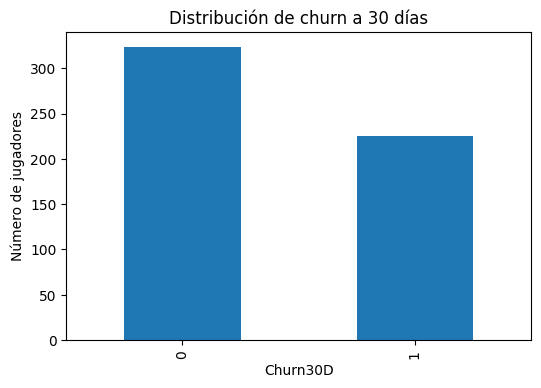

In [ ]:
plt.figure(figsize=(6,4))
df_clean['Churn30D'].value_counts().sort_index().plot(kind='bar')
plt.title('Distribución de churn a 30 días')
plt.xlabel('Churn30D')
plt.ylabel('Número de jugadores')
plt.show()


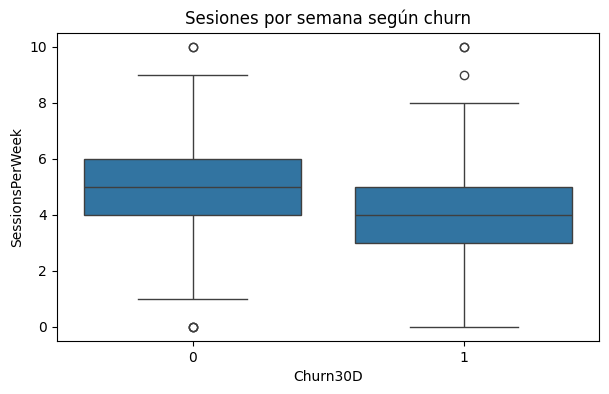

In [ ]:
plt.figure(figsize=(7,4))
sns.boxplot(data=df_clean, x='Churn30D', y='SessionsPerWeek')
plt.title('Sesiones por semana según churn')
plt.show()

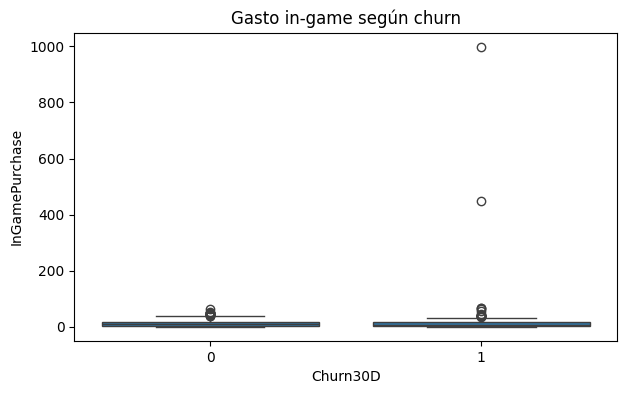

In [ ]:
plt.figure(figsize=(7,4))
sns.boxplot(data=df_clean, x='Churn30D', y='InGamePurchase')
plt.title('Gasto in-game según churn')
plt.show()


In [ ]:
# TODO: calcula el churn medio por plataforma
# Pista: groupby + mean
df_clean.groupby('Platform')['Churn30D'].mean()

,Churn30D
Platform,
CONSOLE,0.474684
MOBILE,0.394231
PC,0.379791


### Preguntas de interpretación
1. ¿Los jugadores con menos sesiones parecen abandonar más?
Sí, el gráfico de caja de 'SessionsPerWeek' vs 'Churn30D' sugiere que los jugadores que abandonan (Churn30D=1) tienden a tener un menor número de sesiones por semana en comparación con los que no abandonan (Churn30D=0).

2. ¿Parece existir relación entre gasto y retención?
Sí, el gráfico de caja de 'InGamePurchase' vs 'Churn30D' indica que los jugadores que abandonan suelen tener un gasto in-game menor, lo que sugiere una relación inversa entre el gasto y la retención.

3. ¿Ves alguna señal útil para un equipo de LiveOps? Las señales clave incluyen:
Baja actividad: Jugadores con pocas sesiones por semana y/o muchos días desde el último inicio de sesión (DaysSinceLastLogin) son candidatos a abandonar.
Bajo gasto: Jugadores que no realizan compras in-game o gastan muy poco.
Diferencias por plataforma: La plataforma 'CONSOLE' tiene la tasa de churn más alta (0.47), lo que indica un problema específico o una oportunidad de mejora en esa plataforma. El equipo de LiveOps podría investigar las razones detrás de este churn más elevado en consolas y diseñar estrategias de retención específicas para estos jugadores (por ejemplo, ofertas personalizadas, eventos exclusivos, mejoras en la experiencia de juego en esa plataforma).


## 7. Preparación para modelado

In [ ]:
y = df_clean['Churn30D']

# Quitamos la variable objetivo y el identificador
X = df_clean.drop(columns=['Churn30D', 'PlayerID'])

# Convertimos variables categóricas a numéricas
X = pd.get_dummies(X, drop_first=True)

print('Dimensiones de X:', X.shape)
display(X.head())


Dimensiones de X: (549, 21)


,Age,SessionsPerWeek,AvgSessionMinutes,DaysSinceLastLogin,PlayerLevel,MatchesPlayedLast30D,WinRate,InGamePurchase,FriendsInGame,UsesVoiceChat,AchievementsUnlocked,ReportsReceivedLast30D,Region_EU,Region_LATAM,Platform_MOBILE,Platform_PC,PreferredGenre_MOBA,PreferredGenre_RPG,PreferredGenre_Shooter,PreferredGenre_Sports,PreferredGenre_Strategy
0,22.0,3,87.0,11,59,14,0.481,7.38,3.0,1,17,0,False,True,False,True,False,True,False,False,False
1,21.0,7,113.0,0,45,24,0.475,11.56,8.0,1,21,2,True,False,False,True,False,False,True,False,False
2,40.0,3,67.0,3,68,27,0.341,0.42,6.0,1,26,1,False,True,True,False,False,False,True,False,False
3,37.0,0,48.0,9,40,39,0.225,8.83,7.0,1,41,2,False,False,False,True,False,False,True,False,False
4,28.0,3,90.0,15,51,15,0.454,23.86,0.0,0,35,1,True,False,False,False,False,False,True,False,False


## 8. Estandarización y PCA

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca_full = PCA()
X_pca_full = pca_full.fit_transform(X_scaled)

var_exp = pca_full.explained_variance_ratio_
var_exp_acum = np.cumsum(var_exp)

display(var_exp[:10])
display(var_exp_acum[:10])


array([0.07785206, 0.0690819 , 0.06474783, 0.06302014, 0.06070585,
       0.05912341, 0.05720869, 0.0528347 , 0.05146624, 0.04824338])

array([0.07785206, 0.14693396, 0.21168179, 0.27470193, 0.33540778,
       0.39453119, 0.45173988, 0.50457459, 0.55604083, 0.6042842 ])

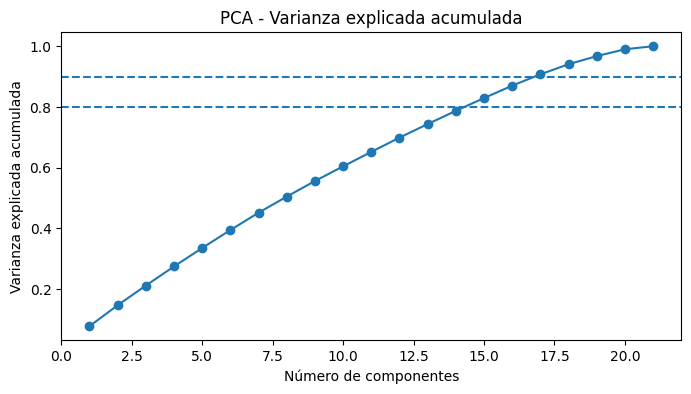

In [ ]:
plt.figure(figsize=(8,4))
plt.plot(range(1, len(var_exp_acum)+1), var_exp_acum, marker='o')
plt.axhline(y=0.80, linestyle='--')
plt.axhline(y=0.90, linestyle='--')
plt.xlabel('Número de componentes')
plt.ylabel('Varianza explicada acumulada')
plt.title('PCA - Varianza explicada acumulada')
plt.show()


In [ ]:
pca_2 = PCA(n_components=2)
X_pca_2 = pca_2.fit_transform(X_scaled)

pca_df = pd.DataFrame(data=X_pca_2, columns=['PC1', 'PC2'])
pca_df['Churn30D'] = y.values




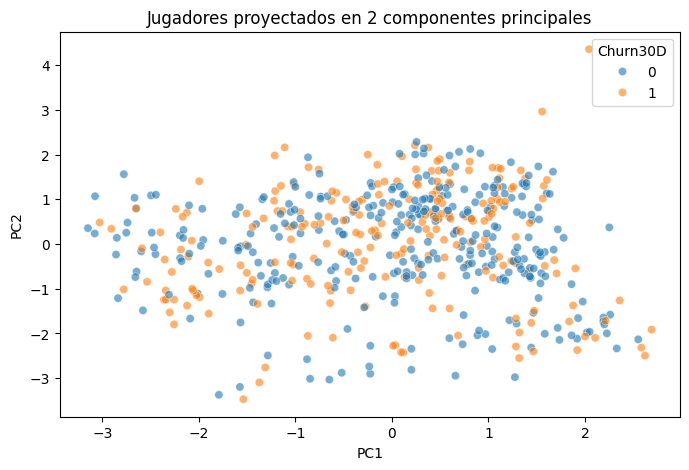

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Churn30D', alpha=0.6)

plt.title('Jugadores proyectados en 2 componentes principales')
plt.show()


### Preguntas de interpretación
1. ¿Se aprecia alguna separación visual entre perfiles?
SessionsPerWeek (Sesiones por semana): Los jugadores con menos sesiones por semana tienden a tener una mayor tasa de churn.
InGamePurchase (Gasto in-game): Los jugadores que realizan menos compras o gastan menos en el juego muestran una mayor probabilidad de churn.
Platform (Plataforma): La plataforma 'CONSOLE' presentó la tasa de churn más alta, sugiriendo que la experiencia o la retención es peor en esta plataforma.
DaysSinceLastLogin (Días desde el último inicio de sesión): Aunque no se graficó explícitamente, es muy probable que un mayor número de días sin iniciar sesión esté fuertemente correlacionado con el churn.
2. ¿Qué ventaja aporta PCA en un problema con muchas variables?
Para el equipo de Retención:
Alertas tempranas: Identificar proactivamente a jugadores con baja actividad (pocas sesiones/semana, muchos días sin iniciar sesión) o bajo gasto y ofrecerles incentivos personalizados (skins, ítems, descuentos, eventos exclusivos) para reengancharlos.
Programas de fidelización: Crear programas que recompensen el tiempo de juego y el gasto, incentivando la continuidad.
Fomentar la interacción social: Promover la adición de amigos y el uso del chat de voz, ya que los jugadores con amigos en el juego y que usan el chat podrían ser más propensos a quedarse.
Para el equipo de Diseño:
Mejorar la experiencia en consolas: Investigar las razones detrás del alto churn en la plataforma 'CONSOLE'. ¿Hay problemas de rendimiento, interfaz de usuario, contenido específico o falta de características?
Contenido atractivo para baja actividad: Diseñar contenido o micro-eventos que requieran menos compromiso de tiempo pero que mantengan a los jugadores interesados.
Para el equipo de Monetización:
Ofertas personalizadas: Dirigir ofertas de compra in-game a jugadores con patrones de gasto bajos pero que aún están activos, buscando convertirlos en compradores más recurrentes.
Bundles y suscripciones: Considerar modelos que ofrezcan valor a largo plazo para fomentar el gasto continuo y la retención
3. ¿Qué inconveniente tiene usar PCA desde el punto de vista de interpretabilidad?
Preparación de datos:
La telemetría de videojuegos a menudo contiene inconsistencias (ej. 'EU' vs 'Europe', 'PC' vs 'pc') y valores atípicos que requieren limpieza y estandarización. La imputación con la mediana es robusta para variables sesgadas o con outliers.
Es crucial unificar categorías y manejar duplicados para asegurar la calidad del dato.
La comprensión del negocio (ej. '¿por qué la mediana en vez de la media?') es clave para tomar decisiones informadas en la limpieza.
PCA (Análisis de Componentes Principales):
Ventaja: Permite reducir la dimensionalidad de un conjunto de datos con muchas variables, lo cual es común en telemetría de juegos. Esto simplifica la visualización (como se ve con los dos primeros componentes principales) y puede mejorar el rendimiento de los modelos al reducir el ruido y la multicolinealidad.
Inconveniente: La interpretabilidad se reduce. Los componentes principales son combinaciones lineales de las variables originales, lo que dificulta entender directamente qué significa un 'PC1' o un 'PC2' en términos de las características originales del juego o del jugador. Esto contrasta con un modelo de regresión logística donde los coeficientes pueden indicar la dirección y magnitud del impacto de cada variable original.


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.25, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)


(411, 21) (138, 21)


In [ ]:
modelo = LogisticRegression(max_iter=2000)
modelo.fit(X_train, y_train)

y_pred = modelo.predict(X_test)


In [ ]:
print('Accuracy:', accuracy_score(y_test, y_pred))
print('\nClassification report:\n')
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
print('Matriz de confusión:')
print(cm)


Accuracy: 0.6376811594202898

Classification report:

              precision    recall  f1-score   support

           0       0.65      0.84      0.73        81
           1       0.61      0.35      0.44        57

    accuracy                           0.64       138
   macro avg       0.63      0.60      0.59       138
weighted avg       0.63      0.64      0.61       138

Matriz de confusión:
[[68 13]
 [37 20]]


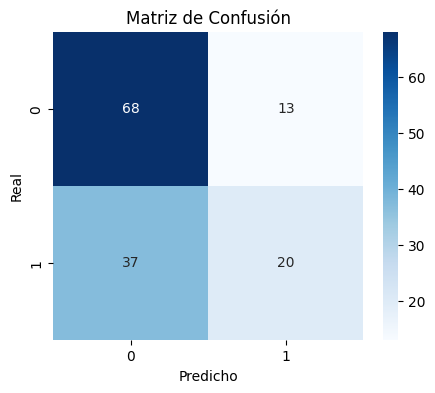

In [ ]:
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.title('Matriz de Confusión')
plt.show()



## 10. Conclusiones finales

Responde brevemente:

1.  **¿Qué variables parecen más relacionadas con el churn?**
    *   **Menos sesiones por semana (`SessionsPerWeek`):** Los jugadores con menor actividad son más propensos a abandonar.
    *   **Menor gasto in-game (`InGamePurchase`):** Hay una correlación entre un bajo gasto y una mayor tasa de churn.
    *   **Plataforma (`Platform`) 'CONSOLE':** Esta plataforma muestra la tasa de churn más alta, lo que sugiere problemas específicos de retención.
    *   **Días desde el último inicio de sesión (`DaysSinceLastLogin`):** Es probable que a mayor número de días sin iniciar sesión, mayor sea la probabilidad de churn.

2.  **¿Qué acciones propondrías al equipo de diseño, retención o monetización?**
    *   **Retención:** Implementar alertas tempranas para jugadores con baja actividad o bajo gasto, ofreciendo incentivos personalizados. Fomentar la interacción social (amigos, chat de voz).
    *   **Diseño:** Investigar las razones del alto churn en 'CONSOLE' y mejorar la experiencia. Diseñar contenido que requiera menos compromiso de tiempo para jugadores menos activos.
    *   **Monetización:** Dirigir ofertas personalizadas a jugadores con patrones de gasto bajos pero activos para aumentar su engagement y gasto.

3.  **¿Qué has aprendido sobre preparación de datos y PCA en un contexto de videojuegos?**
    *   **Preparación de datos:** La telemetría de videojuegos a menudo requiere una limpieza exhaustiva debido a inconsistencias (ej. mayúsculas/minúsculas, sinónimos) y valores atípicos. La imputación con la mediana es una estrategia robusta para variables sesgadas o con outliers. Es crucial unificar categorías y manejar duplicados.
    *   **PCA:** Es una herramienta excelente para la reducción de dimensionalidad en datasets con muchas variables, lo que ayuda en la visualización y puede mejorar el rendimiento de los modelos. Sin embargo, su principal inconveniente es la pérdida de interpretabilidad directa de las variables originales, ya que los componentes son combinaciones lineales abstractas.